In [45]:
from FormUtils import  pyForm, capture_physics_expr

In [46]:
%%pyForm WDecay

* Process: W -> fermion neutrino

#-
* Above suppresses extra output
Off Statistics;
Off FinalStats;
#include amplitude.inc

* Massess
Symbols  ml, mW, gW;
* Polarization 4-vector
Vector n, x, y;


* unpolarized
Local M =   (gW^2/2) * UB(i1, p2, ml) *  (g(i1, i3, mu1)-g(i1, i2, k5) * g(i2, i3, mu1))  * V(i3, p3, 0) * epsM(mu1,q,mW);
#call squareamplitude(M, Msq)
multiply 1/3;
.sort

* polarized
Local MNoPol =  (gW^2/2) * UB(i1, p2, ml) *  (g(i1, i3, mu1)-g(i1, i2, k5) * g(i2, i3, mu1))  * V(i3, p3, 0) ;
#call squareamplitude(MNoPol, MsqNoPol)
.sort
*-------------------------------------------------------------------------*
* Polarization Tensors in W-boson rest frame (q = (mW, 0, 0, 0))
*  n.n = -1
*
*  n = (0, 0, 0, 1) 
* Longitudinal (Z):
* PZ(mu,nu) = n(mu)*n(nu)
* | 0  0  0  0 |
* | 0  0  0  0 |
* | 0  0  0  0 |
* | 0  0  0  1 |
*
* Left-Handed (L):
* PL(mu,nu) = 1/2 * (-d_(mu,nu) + q(mu)*q(nu)/mW^2 - n(mu)*n(nu) + i_*e_(mu,nu,q,n)/mW)
*     | 0  0   0  0 |
* 1/2 | 0  1   i  0 |
*     | 0 -i   1  0 |
*     | 0  0   0  0 |
*
* Right-Handed (R):
* PR(mu,nu) = 1/2 * (-d_(mu,nu) + q(mu)*q(nu)/mW^2 - n(mu)*n(nu) - i_*e_(mu,nu,q,n)/mW)
*     | 0  0   0  0 |
* 1/2 | 0  1  -i  0 |
*     | 0  i   1  0 |
*     | 0  0   0  0 |
*-------------------------------------------------------------------------*
Local MsqPolZ = MsqNoPol * n(mu1) * n(mu2); 
Local MsqPolL = MsqNoPol * 1/2 * ((-d_(mu1,mu2) + q(mu1)*q(mu2)/mW^2 - n(mu1) * n(mu2)) + e_(mu1,mu2,q,n)/mW ) ; 
Local MsqPolR = MsqNoPol * 1/2 *((-d_(mu1,mu2) + q(mu1)*q(mu2)/mW^2 - n(mu1) * n(mu2)) - e_(mu1,mu2,q,n)/mW ) ; 
.sort
id e_(q, n, mu1, mu2) * e_(p2, p3, mu1, mu2) = -2 * (q.p2 * n.p3 - q.p3 * n.p2);
.sort
id n.n = -1 ;
.sort

* --- Kinematics ---
id q.q = mW^2;
id p3.p3 = 0;
id p2.p3 = (mW^2 - ml^2)/2;
id q.p2 = (mW^2 + ml^2)/2;
id q.p3 = (mW^2 - ml^2)/2;
.sort


* Save to file 
Format C;
#write <WDecay.txt> "%e;", Msq;
#write <WDecayPolZ.txt> "%e;", MsqPolZ;
#write <WDecayPolL.txt> "%e;", MsqPolL;
#write <WDecayPolR.txt> "%e;", MsqPolR;
.sort
* Print 
Format;
Print Msq;
Print MsqPolZ;
Print MsqPolL;
Print MsqPolR;

.end

FORM 5.0.0 (Jan 27 2026, v5.0.0)                 Run: Mon Apr 13 01:25:35 2026
    
    * Process: W -> fermion neutrino
    
    #-

   Msq =
      2/3*mW^2*gW^4 - 1/3*ml^2*gW^4 - 1/3*ml^4*mW^(-2)*gW^4;

   MsqPolZ =
      mW^2*gW^4 - ml^2*gW^4 + 4*p2.n*p3.n*gW^4;

   MsqPolL =
      1/2*mW^2*gW^4 - 1/2*ml^4*mW^(-2)*gW^4 - 2*p2.n*p3.n*gW^4 - p2.n*mW*gW^4
       + p2.n*ml^2*mW^(-1)*gW^4 + p3.n*mW*gW^4 + p3.n*ml^2*mW^(-1)*gW^4;

   MsqPolR =
      1/2*mW^2*gW^4 - 1/2*ml^4*mW^(-2)*gW^4 - 2*p2.n*p3.n*gW^4 + p2.n*mW*gW^4
       - p2.n*ml^2*mW^(-1)*gW^4 - p3.n*mW*gW^4 - p3.n*ml^2*mW^(-1)*gW^4;




<|M^2|> =  2*gW**4*mW**2/3
<|M^2|> PolZ=  gW**4*(mW**2 + 4*p2_n*p3_n)
<|M^2|> PolL=  gW**4*(mW**2 - 2*mW*p2_n + 2*mW*p3_n - 4*p2_n*p3_n)/2
<|M^2|> PolR=  gW**4*(mW**2 + 2*mW*p2_n - 2*mW*p3_n - 4*p2_n*p3_n)/2
<|M^2|> PolZ=  gW**4*mW**2*sin(theta)**2
<|M^2|> PolL=  gW**4*mW**2*(cos(theta) + 1)**2/2
<|M^2|> PolR=  gW**4*mW**2*(cos(theta) - 1)**2/2


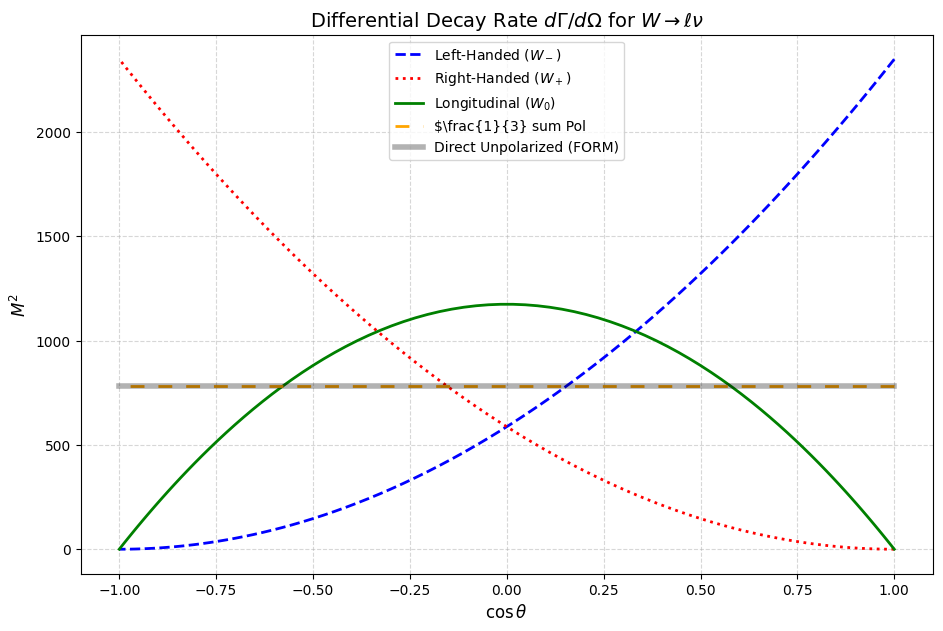

In [47]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from Kinematics import dGamma_dOmega

plt.style.use("seaborn-v0_8-muted")
plt.rcParams["axes.grid"] = True

# Unpolarized
form_expr = capture_physics_expr("scripts/WDecay.txt")
mW, gW, ml= sp.symbols("mW gW ml")
Msq = sp.simplify(form_expr, rational=True).subs(ml, 0)
print(f"<|M^2|> =  {Msq}")

#Polarized 
form_expr_PolZ = capture_physics_expr("scripts/WDecayPolZ.txt")
form_expr_PolL = capture_physics_expr("scripts/WDecayPolL.txt")
form_expr_PolR = capture_physics_expr("scripts/WDecayPolR.txt")
p2_n, p3_n =  sp.symbols("p2_n, p3_n")
Msq_PolZ = sp.simplify(form_expr_PolZ,rational=True).subs(ml, 0)
Msq_PolL = sp.simplify(form_expr_PolL,rational=True).subs(ml, 0)
Msq_PolR = sp.simplify(form_expr_PolR,rational=True).subs(ml, 0)
print(f"<|M^2|> PolZ=  {Msq_PolZ}")
print(f"<|M^2|> PolL=  {Msq_PolL}")
print(f"<|M^2|> PolR=  {Msq_PolR}")


# p2 (Lepton)  = [E_lep, p_mag*sin(theta), 0, p_mag*cos(theta)]
# p3 (Neutrino)= [p_mag, -p_mag*sin(theta), 0, -p_mag*cos(theta)]
#  p_mag = mW / 2
# n is [0, 0,0,1] 
theta = sp.Symbol("theta", real=True)
subs = {
    p2_n: -(mW/2) * sp.cos(theta),
    p3_n:  (mW/2) * sp.cos(theta)  # p3 is opposite to p2 in rest frame
}

Msq_L = sp.simplify(Msq_PolL.subs(subs))
Msq_R = sp.simplify(Msq_PolR.subs(subs))
Msq_0 = sp.simplify(Msq_PolZ.subs(subs))
print(f"<|M^2|> PolZ=  {Msq_0}")
print(f"<|M^2|> PolL=  {Msq_L}")
print(f"<|M^2|> PolR=  {Msq_R}")

physics_vals = {mW: 80.379, gW: 0.653}
angles = np.linspace(0, np.pi, 100)
x_vals = np.cos(angles)
f_L = sp.lambdify(theta, Msq_L.subs(physics_vals), 'numpy')
f_R = sp.lambdify(theta, Msq_R.subs(physics_vals), 'numpy')
f_0 = sp.lambdify(theta, Msq_0.subs(physics_vals), 'numpy')

pol_L= f_L(angles)
pol_R= f_R(angles)
pol_0= f_0(angles)
sumAvgPol = (pol_L+pol_R+pol_0)/3

unpol = np.full_like(angles, Msq.subs(physics_vals).evalf())

plt.figure(figsize=(11, 7))
# Plot Individual Polarizations
plt.plot(x_vals, pol_L, label=r'Left-Handed ($W_-$)', linestyle='--', color='blue', lw=2)
plt.plot(x_vals, pol_R, label=r'Right-Handed ($W_+$)', linestyle=':', color='red', lw=2)
plt.plot(x_vals, pol_0 , label=r'Longitudinal ($W_0$)', linestyle='-', color='green', lw=2)
plt.plot(x_vals, sumAvgPol, label=r'$\frac{1}{3} sum Pol', color='orange', ls=(0, (5, 5)), lw=2)
plt.plot(x_vals, unpol, label='Direct Unpolarized (FORM)', color='black', lw=4, alpha=0.3)

# Formatting
plt.title(r"Differential Decay Rate $d\Gamma/d\Omega$ for $W \to \ell \nu$", fontsize=14)
plt.xlabel(r"$\cos \theta$ ", fontsize=12)
plt.ylabel(r"$M^2$", fontsize=12)
plt.legend(frameon=True, loc='upper center')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
